Test JaxTracer on Hydro Turbulence - Turb Box M2MA2

Import Libs

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
from pathlib import Path

home = str(Path.home())
sys.path.append(home + '/dev')

from PLASMAtools.read_funcs.read import Fields
from MagPy.Imaging import Image

#add path
sys.path.insert(0, '../../../src/')     # import path/to/synthpy

import simulator.config as config
config.jax_init()

import simulator.beam as beam_initialiser
import simulator.domain as d
import simulator.propagator as p
import processing.diagnostics as diag

import utils.handle_filetypes as utilIO
import jax.numpy as jnp
import yt


import importlib
importlib.reload(beam_initialiser)
importlib.reload(d)
importlib.reload(p)
importlib.reload(diag)

pyfftw not installed, using scipy's serial fft
pyfftw not installed, using scipy's serial fft


/rds/general/user/sm13118/home/miniforge3/envs/gpu-env/lib/python3.11/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Setting top level path for imports: /rds/general/user/sm13118/home/dev/synthPy/src

Disabling python multi-threading...
Initialising jax...

Default jax backend: gpu
Available devices: [CudaDevice(id=0)]


<module 'processing.diagnostics' from '/rds/general/user/sm13118/home/dev/synthPy/src/processing/diagnostics.py'>

Import domain

In [3]:
ds = yt.load("~/Research/Synthetic/Data/TurbBox_JB/M6MA05/Turb_hdf5_plt_cnt_0050")
fields = Fields(filename = "/rds/general/user/sm13118/home/Research/Synthetic/Data/TurbBox_JB/M6MA05/Turb_hdf5_plt_cnt_0050", reformat = True)
fields.read("dens");                         # Density Field

ne = 5e23 * fields.dens[0,:,:,:]

dims = ne.shape
spacing = [1/dims[0], 1/dims[1], 1/dims[2]]


yt : [INFO     ] 2025-09-04 10:18:10,472 Cannot find Gamma
yt : [INFO     ] 2025-09-04 10:18:10,521 Parameters: current_time              = 0.4166668
yt : [INFO     ] 2025-09-04 10:18:10,522 Parameters: domain_dimensions         = [576 576 576]
yt : [INFO     ] 2025-09-04 10:18:10,522 Parameters: domain_left_edge          = [-0.5 -0.5 -0.5]
yt : [INFO     ] 2025-09-04 10:18:10,523 Parameters: domain_right_edge         = [0.5 0.5 0.5]
yt : [INFO     ] 2025-09-04 10:18:10,523 Parameters: cosmological_simulation   = 0


Reading in grid attribute: dens
Reading in reformatted grid attribute: dens


In [4]:

extent_x = ((dims[0]*spacing[0])/2)*1e-2
extent_y = ((dims[1]*spacing[1])/2)*1e-2
extent_z = ((dims[2]*spacing[2])/2)*1e-2

lengths = 2 * jnp.array([extent_x, extent_y, extent_z], dtype = jnp.float32)
print(lengths)

ne_x = np.linspace(-extent_x,extent_x, dims[0])
ne_y = np.linspace(-extent_y,extent_y, dims[1])
ne_z = np.linspace(-extent_z,extent_z, dims[2])

print(f'extent x: {extent_x}')
print(f'extent y: {extent_y}')
print(f'extent z: {extent_z}')

print(f'dims x: {dims[0]}')
print(f'dims y: {dims[1]}')
print(f'dims z: {dims[2]}')

print("\n\n")

# is this baseline not decreasing after each run? - testing manually deleting objects first
# baseline = memory_report()['used_raw']
probing_direction = 'z'

Np = 5e7

domain = d.ScalarDomain(lengths, dims, leeway_factor = 3, ne_type = "import", probing_direction = probing_direction, Np = Np, ne = ne)

del ne_x
del ne_y
del ne_z
del ne

[0.01 0.01 0.01]
extent x: 0.005
extent y: 0.005
extent z: 0.005
dims x: 576
dims y: 576
dims z: 576



Predicted size in memory of domain: 729.0 MB

Memory prior to domain creation:
 - total : 24.0 GB
 - free  : 23.291015625 GB
 - used  : 726.0 MB

Est. ray size in memory: 102.81801223754883 GB
Est. domain memory limit: 4.271484375 GB
 --> inc. +200.0% variance margin
Total estimated maximum: 312.7255210876465 GB

ESTIMATE SUGGESTS DOMAIN + RAYS CANNOT FIT IN AVAILABLE MEMORY.
 --> Auto-batching rays based on memory available and domain size estimate...
 --> Can't auto-batch the domain as it is imported (limitation will be resolved in the future)

Coordinates have shape of (576, 576, 576) --> no padding required.

Using imported ne domain. Be careful that your import matches with other passed variables, this is not sanity checked by the init function.


Tracing using JaxTracer

4.4131197e+25


0.005

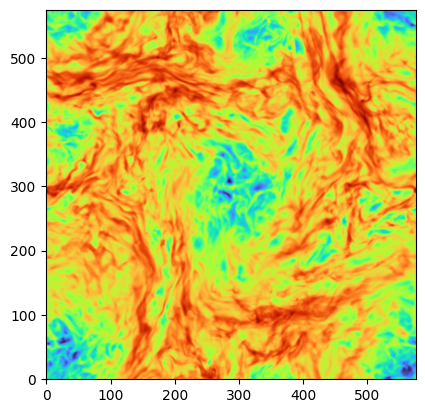

In [5]:
print(domain.ne.T.max())
plt.imshow(np.trapezoid(domain.ne[:,:,:],dx=1/dims[2], axis = 2), origin="lower",cmap='turbo', norm="log")
extent_z

In [6]:
# define beam parameters
lwl            =  532e-9
beam_size      =  [extent_x, extent_y]    # beam radius
probing_extent =  extent_z
ne_extent      =  probing_extent  # so the beam knows where to initialise initial positions
divergence     =  0.05e-3
beam_type      =  "rectangular"

rf, _, duration = p.solve((beam_size, divergence, ne_extent, probing_direction, beam_type, False), domain, probing_extent, verbose = False)


Number of domain batches: 1
Number of ray batches: 14

Est. size in memory of rays (1 = 736 B): 2.4480475187301636 GB
Est. potential size in memory of total rays: 34.27267074584961 GB
 --> Np (total) = 50000000 (in 14 batches) - 3571428 for this batch

No need to generate any sections of the domain, batching not utilised.
 --> tracing a depth of 0.005 mm's to the target depth of 0.005 mm's

Running device: gpu
There are 1 available GPU devices: [CudaDevice(id=0)]

jax compilation of solver took: 0.0004291534423828125 seconds
Est. size in memory of rays (1 = 736 B): 2.4480475187301636 GB
Est. potential size in memory of total rays: 34.27267074584961 GB
 --> Np (total) = 50000000 (in 14 batches) - 3571428 for this batch

No need to generate any sections of the domain, batching not utilised.
 --> tracing a depth of 0.005 mm's to the target depth of 0.005 mm's

Running device: gpu
There are 1 available GPU devices: [CudaDevice(id=0)]

jax compilation of solver took: 0.0004024505615234375 

In [7]:
import processing.diagnostics as diag

shadowgrapher = diag.Shadowgraphy(lwl, rf, focal_plane = 1)
shadowgrapher.single_lens_solve()
shadowgrapher.histogram(bin_scale = 1, clear_mem = False)

refractometer = diag.Refractometry(lwl, rf, focal_plane = 1)
refractometer.incoherent_solve()
refractometer.histogram(bin_scale = 1, clear_mem = False)



50000000 rays received, 40112137 incident on the first lens.
 --> 19.800001 % of rays wasted!

rf size expected: [40112137. 40112137.]
rf after clearing nan's: [40111730. 40111730.]

50000000 rays received, 40112137 incident on the first lens.
 --> 19.800001 % of rays wasted!

rf size expected: [40112137. 40112137.]
rf after clearing nan's: [40111730. 40111730.]


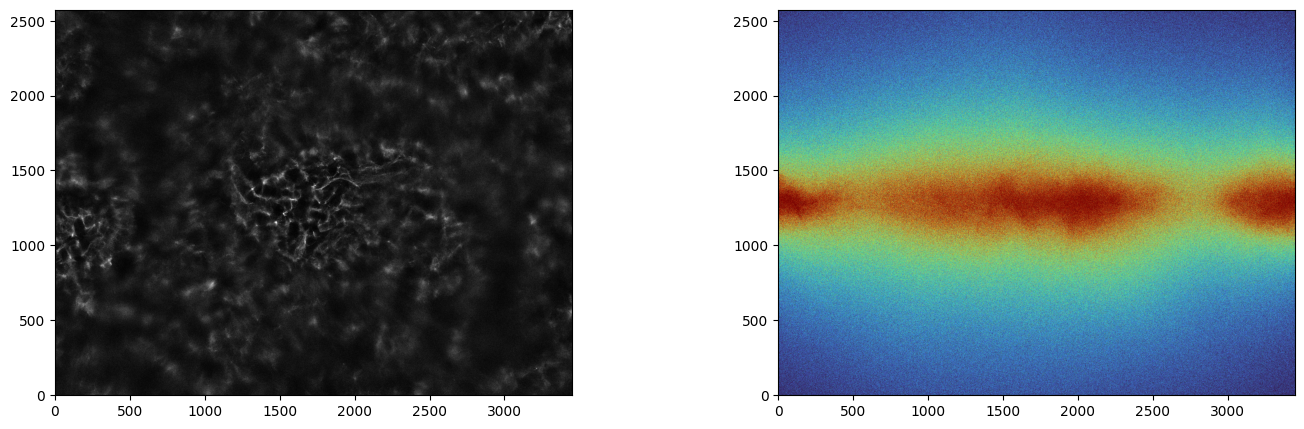

In [8]:
fig = plt.figure(figsize=(16, 6))
outer_grid = fig.add_gridspec(1,2, height_ratios = [1], width_ratios=[0.5, 0.5], wspace=0.4)

# Subplots
ax0 = fig.add_subplot(outer_grid[0, 0])
ax1 = fig.add_subplot(outer_grid[0, 1])

ax0.imshow(shadowgrapher.H, origin = "lower", cmap = "Greys_r", clim = [0,30])
ax1.imshow(refractometer.H, origin = "lower", cmap = "turbo", clim = [0,10])

In [9]:
scale_sh_x   =  shadowgrapher.H.shape[1]/9
scale_sh_y   =  shadowgrapher.H.shape[0]/6.75

L = 400 # distance from the volume to the lens (for a single lens system - 300 mm)

pixel_size  = (13.5/refractometer.H.shape[0])  # pixel size, mm/px in this case because bin = 10, pixel size = 52 um instead 5.4 um
scale_phi   =   1/(2 * pixel_size/L * 1000)  #sensitivity is Lϕ/2, ϕ in radians, convert to mradians.

shadow_sh  =     Image(shadowgrapher.H, 0, scale_sh_x, scale_sh_y, fliplr = False)
o_sh       =     (int(shadowgrapher.H.shape[1]/2), int(shadowgrapher.H.shape[0]/2))
shadow_sh.set_origin(o_sh)

refr_sh    =     Image(refractometer.H, 0., scale_sh_x, scale_phi, fliplr = False)
o_rh       =       (int(refractometer.H.shape[1]/2), int(refractometer.H.shape[0]/2))
refr_sh.set_origin(o_rh)


Text(0.5, 1.0, 'Refraction Shadowgraph')

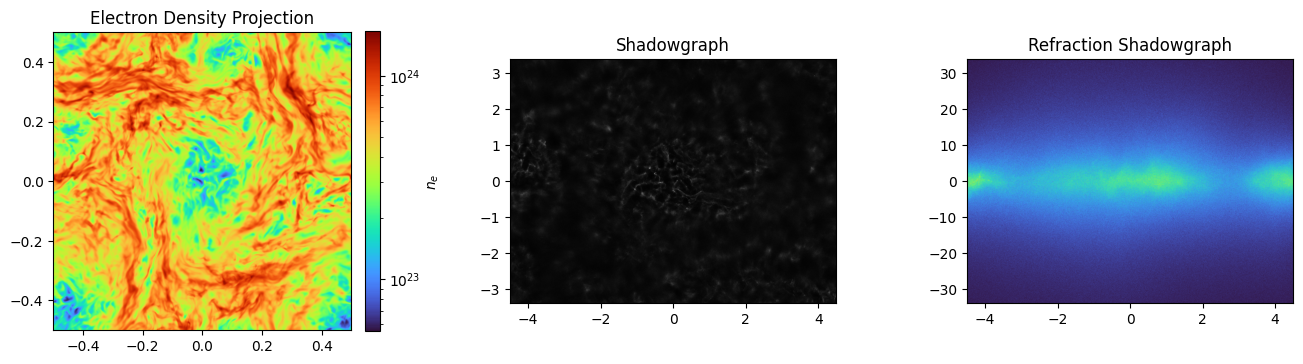

In [10]:
from matplotlib.colors import LogNorm

fig = plt.figure(figsize=(16, 6))
outer_grid = fig.add_gridspec(1, 3, height_ratios = [1], width_ratios=[0.5, 0.5, 0.5], wspace=0.4)

# Subplots
ax0 = fig.add_subplot(outer_grid[0, 0])
ax1 = fig.add_subplot(outer_grid[0, 1])
ax2 = fig.add_subplot(outer_grid[0, 2])

# Electron density map
ne_proj = np.trapezoid(domain.ne[:,:,:], dx=1/dims[2], axis=2)
im0 = ax0.imshow(
    ne_proj,
    extent=[-0.5, 0.5, -0.5, 0.5],
    origin="lower",
    cmap="turbo",
    norm=LogNorm()
)
fig.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04, label=r"$n_e$")

# Shadowgraphs
shadow_sh.plot_mm(ax1, cmap="Greys_r", aspect=scale_sh_y/scale_sh_x)
refr_sh.plot_mm(ax2, cmap="turbo", aspect=scale_phi/scale_sh_x, clim = [refr_sh.im.min(), refr_sh.im.max()])

# Titles (optional)
ax0.set_title("Electron Density Projection")
ax1.set_title("Shadowgraph")
ax2.set_title("Refraction Shadowgraph")

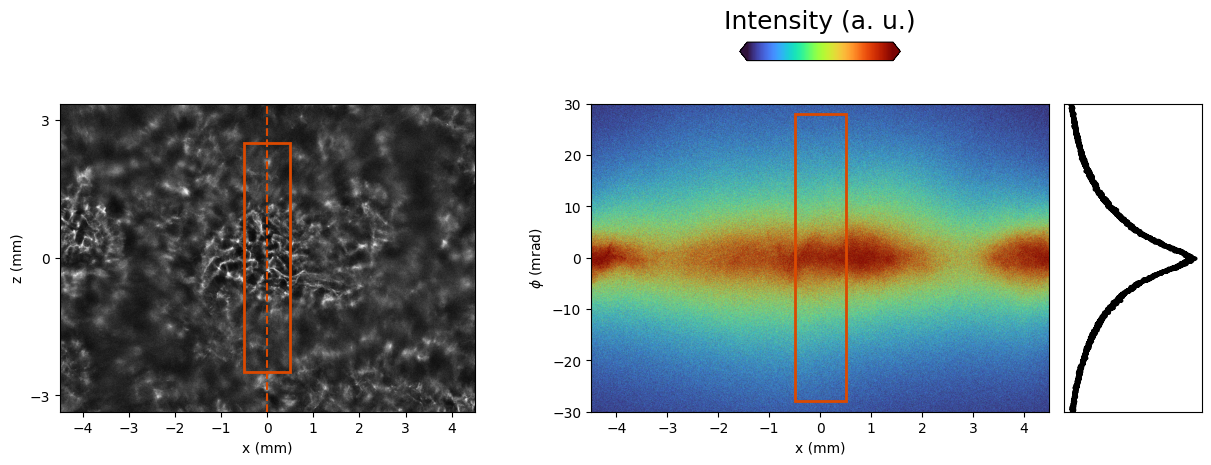

In [11]:
from matplotlib.gridspec import GridSpec
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1 import make_axes_locatable

c1 = '#1C6758'  
c2 = '#006e23'
c3 = '#6e0052'   
c4 = '#db4900' 
b  = '#044582'

color = [c4, c3, c1]

fig = plt.figure(figsize = (16, 4))

gs = GridSpec(nrows=1, ncols=2, wspace=0.03, width_ratios=[0.5, 0.5])

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])

axis = [ax0, ax1]
stds_list_bins = []
error_stds_list = []

aspect  = scale_phi / scale_sh_x
shadow_sh.plot_mm(ax0, cmap = 'Greys_r', aspect = scale_sh_y/scale_sh_x, clim = [0,7e-9])

im1 = refr_sh.plot_mm(ax1, multiply_by = 1, aspect  = aspect, cmap = 'turbo', clim = [0,5e-9])

ax0.set_xlabel('x (mm)')
ax0.set_ylabel('z (mm)')
ax0.set_ylim(-3.355,3.355)
ax0.set_yticks([-3, 0, 3])
ax0.set_xlim(-4.5,4.5)

# ------------------------------------
start_x = -0.5
end_x   = 0.5
rect = patches.Rectangle((start_x, -2.5),np.abs(end_x-start_x), 5, linewidth=2, edgecolor=color[0], facecolor='none')
# Add the patch to the Axes
ax0.add_patch(rect)

rect = patches.Rectangle((start_x, -28), np.abs(end_x-start_x), 56, linewidth=2, edgecolor=color[0], facecolor='none')
# Add the patch to the Axes
ax1.add_patch(rect)

ax0.axvline(x = 0., c = color[0], ls = "--")

# ---------------------------------------------------------------------------------------------------------------------------------------
axins1 = inset_axes(
ax1,
width="35%",  # width: 50% of parent_bbox width
height="6%",  # height: 5%
loc="upper center",
bbox_to_anchor=(0., 0.2, 1, 1),
bbox_transform=ax1.transAxes,
borderpad=0,
)
axins1.xaxis.set_ticks_position("bottom")
cbar = plt.colorbar(im1, cax=axins1, ticks=[0.035, 0.3], shrink=0.2, orientation="horizontal", extend='both')
cbar.set_label(r'Intensity (a. u.)', fontsize = 18, rotation = 0, labelpad = 10)
cbar.ax.tick_params(labelsize = 16)
cbar.ax.xaxis.set_label_position('top')

ax1.set_xlim(-4.5,4.5) 
ax1.set_xlabel(r"x (mm)")
ax1.set_ylim(-30,30)
ax1.set_aspect('auto')
# ax1.set_yticks([-15,-10,-5, 0, 5, 10, 15])
ax1.grid(False)
ax1.set_ylabel(r"$\phi$ (mrad)")

divider = make_axes_locatable(ax1)
axhoriz = divider.append_axes('right', size='30%', pad=0.15)
axhoriz.set_ylim(-30,30)

axhoriz.set_yticks([]);
axhoriz.set_xticks([]);

cut_y0 = refr_sh.mm_to_px([start_x, -30])[1]
cut_y1 = refr_sh.mm_to_px([end_x, 30])[1]
cut_x0 = refr_sh.mm_to_px([start_x, -30])[0]  
cut_x1 = refr_sh.mm_to_px([end_x, 30])[0]  

profile_vert           =    refr_sh.im[cut_y1:cut_y0, cut_x0:cut_x1].sum(axis = 1)
profile_vert           =    profile_vert / profile_vert.max()
cut_x0_mm, cut_y0_mm   =    refr_sh.px_to_mm([cut_x0, cut_y0])
cut_x1_mm, cut_y1_mm   =    refr_sh.px_to_mm([cut_x1, cut_y1])

hor_x                   =   np.linspace(cut_y0_mm, cut_y1_mm, len(profile_vert))
axhoriz.plot(profile_vert, hor_x, lw = 3, c = 'k', alpha = 1)

# axhoriz.legend(loc='upper center', fontsize = 9)

# error = np.sqrt(np.diag(pcov))

# text = r'$\sigma_\phi^2$ = ' + str(np.round(popt[2],3 )) + ' mrad\n' + "$\epsilon_\sigma^2$ = $\pm$ " + str(np.round(error[2], 3)) + " mrad"
# axhoriz.text(1.15, -0.15, text, size=10,
#         va="center", ha="center", multialignment="center",
#         bbox=dict(ec = 'k', lw = 2, fc="none"), transform=axis[i+1].transAxes)

# axhoriz.text(1.19, 1.08, 'y = '+str(20) + ' mm', size=16,
#         va="center", ha="center", multialignment="center",
#         bbox=dict(ec = 'none', fc="none"), transform=axis[i+1].transAxes)

# stds_list_bins.append(std)
# error_stds_list.append(error[2])

# fig.savefig('./xyz000_doublemesh_shadow_lineout_extent_1064nm_Np_2e6_histogram_refr.png', bbox_inches='tight', dpi=200)

Text(0.5, 1.0, 'Gaussian Fit with Baseline Removed')

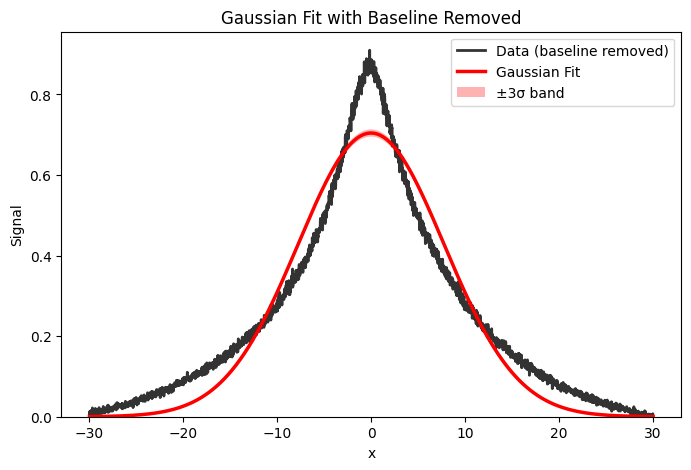

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from lmfit.models import GaussianModel

# --- Baseline removal (subtract minimum) ---
profile_corr = profile_vert - 0.09

# --- Build Gaussian model ---
mod = GaussianModel()

# Initial guess from data
params = mod.guess(profile_corr, x=hor_x)

# Fit
res = mod.fit(profile_corr, x=hor_x, nan_policy='omit')

# Uncertainty band (e.g. ±3σ)
nstd = 3
unc = res.eval_uncertainty(sigma=nstd)

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.plot(hor_x, profile_corr, lw=2, c='k', alpha=0.8, label="Data (baseline removed)")

plt.plot(hor_x, res.best_fit, color="r", lw=2.5, label="Gaussian Fit")
plt.fill_between(
    hor_x,
    res.best_fit - unc,
    res.best_fit + unc,
    color="r",
    alpha=0.3,
    edgecolor="none",
    label=f"±{nstd}σ band"
)

plt.ylim(bottom=0)
# plt.xlim(-10, 10)
plt.legend()
plt.xlabel("x")
plt.ylabel("Signal")
plt.title("Gaussian Fit with Baseline Removed")

# Extract fit